<a href="https://colab.research.google.com/github/CemBC/FabricAccuracyTables/blob/master/Haptic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
import joblib
import numpy as np
from urllib.parse import unquote
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

fabric_mapping = {
    "pamuk": "cotton",
    "denim": "denim",
    "ipek": "silk",
    "yün": "wool",
    "keten": "linen",
    "sentetik": "synthetic"
}

try:
    df_csv = pd.read_csv('fabric_file.csv')
    print("CSV loaded successfully.")
except:
    print("ERROR: 'fabric_file.csv' not found! Please upload it to Colab.")

def clean_text(text):
    text = unquote(str(text))
    match = re.search(r'/([^/]+)-p-\d+', text)
    if match: text = match.group(1)
    else: text = text.split('/')[-1]

    text = text.replace('İ', 'i').replace('I', 'ı').lower()
    text = re.sub(r'[^a-zığüşöç ]', ' ', text)
    return text.strip()

pure_samples = [
    ("100 pamuk cotton materyal penye yumuşak dogal", "cotton"),
    ("denim pantolon kot jean materyal indigo blue", "denim"),
    ("100 ipek silk materyal saten satin parlak şifon", "silk"),
    ("100 yün wool triko kazak hırka sıcak tutan kase kaşe", "wool"),
    ("keten linen nefes alan yazlık doğal kumaş", "linen"),
    ("polyester sentetik naylon parlak esnek likra", "synthetic")
]

df_csv['clean_text'] = df_csv['URL'].apply(clean_text)

def translate_label(label):
    label = str(label).lower().strip()
    return fabric_mapping.get(label, label)

final_data = []
for text, label in pure_samples:
    for _ in range(100):
        final_data.append({'text': text, 'label': label})

for _, row in df_csv.iterrows():
    english_label = translate_label(row['Fabric_Type'])
    final_data.append({'text': row['clean_text'], 'label': english_label})

df_final = pd.DataFrame(final_data)

tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X = tfidf.fit_transform(df_final['text'])

le = LabelEncoder()
y = le.fit_transform(df_final['label'])

models = {
    'rf': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'lr': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'nb': MultinomialNB(),
    'svm': CalibratedClassifierCV(LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
}

print("\n--- TRAINING STARTED ---")
for name, model in models.items():
    model.fit(X, y)
    joblib.dump(model, f'model_{name}.pkl')
    print(f"✓ {name.upper()} Model trained and saved.")

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("\n--- PROCESS COMPLETED ---")
print("Saved Files:\n1. model_rf.pkl\n2. model_lr.pkl\n3. model_nb.pkl\n4. model_svm.pkl\n5. tfidf_vectorizer.pkl\n6. label_encoder.pkl")

CSV loaded successfully.

--- TRAINING STARTED ---
✓ RF Model trained and saved.
✓ LR Model trained and saved.
✓ NB Model trained and saved.
✓ SVM Model trained and saved.

--- PROCESS COMPLETED ---
Saved Files:
1. model_rf.pkl
2. model_lr.pkl
3. model_nb.pkl
4. model_svm.pkl
5. tfidf_vectorizer.pkl
6. label_encoder.pkl


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving trendyol_dataset_links.csv to trendyol_dataset_links.csv


In [ ]:
import os
print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'model_nb.pkl', 'model_lr.pkl', 'trendyol_dataset_links.csv', 'model_rf.pkl', 'label_encoder.pkl', 'model_svm.pkl', 'sample_data']


In [ ]:
import pandas as pd
import re
import joblib
import numpy as np
from urllib.parse import unquote
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv("trendyol_dataset_links.csv")

if "URL" in df.columns and "url" not in df.columns:
    df = df.rename(columns={"URL": "url"})
if "Fabric_Type" in df.columns and "label" not in df.columns:
    df = df.rename(columns={"Fabric_Type": "label"})


fabric_mapping = {
    "pamuk": "cotton",
    "cotton": "cotton",

    "ipek": "silk",
    "silk": "silk",

    "kot": "denim",
    "denim": "denim",

    "yün": "wool",
    "yun": "wool",
    "wool": "wool",

    "keten": "linen",
    "linen": "linen",

    "sentetik": "synthetic",
    "synthetic": "synthetic",

    "other": "other"
}

def normalize_label(label):
    label = str(label).strip().lower()
    return fabric_mapping.get(label, label)

df["label"] = df["label"].apply(normalize_label)


def clean_text(text):
    text = unquote(str(text))
    text = text.split("?")[0]

    match = re.search(r'/([^/]+)-p-\d+', text)
    if match:
        text = match.group(1)
    else:
        text = text.replace("https://", "").replace("www.", "")
        text = re.sub(r"[/_\-]", " ", text)

    text = text.replace("İ", "i").replace("I", "ı").lower()
    text = re.sub(r"[^a-zığüşöç ]", " ", text)
    return " ".join(text.split()).strip()

df["clean_text"] = df["url"].apply(clean_text)


tfidf = joblib.load("tfidf_vectorizer.pkl")
le = joblib.load("label_encoder.pkl")

models = {}
for name in ["rf", "lr", "nb", "svm"]:
    models[name] = joblib.load(f"model_{name}.pkl")

print("Loaded label classes:", list(le.classes_))
print("Loaded models:", list(models.keys()))


X = tfidf.transform(df["clean_text"])


valid_eval_labels = ["denim", "silk", "cotton", "wool"]
df_eval = df[df["label"].isin(valid_eval_labels)].copy()

if len(df_eval) != len(df):
    print(f"Warning: {len(df) - len(df_eval)} rows were excluded because their labels are outside the four target classes.")

X_eval = tfidf.transform(df_eval["clean_text"])


technical_keywords = [
    "pamuk", "ipek", "yün", "keten",
    "cotton", "wool", "silk", "linen",
    "denim", "kot"
]

threshold = 0.35

all_probs = []
model_preds = {}

for name, model in models.items():
    probs = model.predict_proba(X_eval)
    preds = model.predict(X_eval)

    all_probs.append(probs)
    model_preds[name] = le.inverse_transform(preds)

avg_probs = np.mean(all_probs, axis=0)

best_indices = np.argmax(avg_probs, axis=1)
raw_confidences = np.max(avg_probs, axis=1)
raw_predicted_labels = le.inverse_transform(best_indices)

score_with_bonus = []
predicted_labels = []

for i, cleaned in enumerate(df_eval["clean_text"]):
    bonus = 1.2 if any(keyword in cleaned for keyword in technical_keywords) else 1.0
    final_score = raw_confidences[i] * bonus
    score_with_bonus.append(final_score)

    if final_score < threshold:
        predicted_labels.append("other")
    else:
        predicted_labels.append(normalize_label(raw_predicted_labels[i]))

df_eval["predicted_label"] = predicted_labels
df_eval["raw_confidence"] = raw_confidences
df_eval["score_with_bonus"] = score_with_bonus
df_eval["confidence_percent"] = np.minimum(np.array(score_with_bonus) * 100, 99).astype(int)

# Add single model predictions
for name in models.keys():
    df_eval[f"pred_{name}"] = [normalize_label(x) for x in model_preds[name]]


y_true_labels = df_eval["label"].tolist()
y_pred_labels = df_eval["predicted_label"].tolist()

labels_for_report = ["denim", "silk", "cotton", "wool", "other"]

acc = accuracy_score(y_true_labels, y_pred_labels)

print(f"\nApp.py Compatible Soft Voting Accuracy: {acc:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels_for_report)
print("Label order:", labels_for_report)
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true_labels,
    y_pred_labels,
    labels=labels_for_report,
    zero_division=0
))


df_eval["is_correct"] = (df_eval["label"] == df_eval["predicted_label"]).astype(int)

df_eval.to_csv("evaluation_results_app_compatible.csv", index=False, encoding="utf-8-sig")

print("\nSaved: evaluation_results_app_compatible.csv")
print("\nFirst 10 results:")
print(df_eval[[
    "url",
    "label",
    "predicted_label",
    "is_correct",
    "raw_confidence",
    "score_with_bonus",
    "confidence_percent"
]].head(10))

Loaded label classes: ['cotton', 'denim', 'linen', 'nan', 'silk', 'synthetic', 'wool']
Loaded models: ['rf', 'lr', 'nb', 'svm']

App.py Compatible Soft Voting Accuracy: 0.8675

Confusion Matrix:
Label order: ['denim', 'silk', 'cotton', 'wool', 'other']
[[ 97   0   1   0   2]
 [  1  87   6   2   4]
 [  0   1  63   8  28]
 [  0   0   0 100   0]
 [  0   0   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

       denim       0.99      0.97      0.98       100
        silk       0.99      0.87      0.93       100
      cotton       0.90      0.63      0.74       100
        wool       0.91      1.00      0.95       100
       other       0.00      0.00      0.00         0

    accuracy                           0.87       400
   macro avg       0.76      0.69      0.72       400
weighted avg       0.95      0.87      0.90       400


Saved: evaluation_results_app_compatible.csv

First 10 results:
                                                 url 

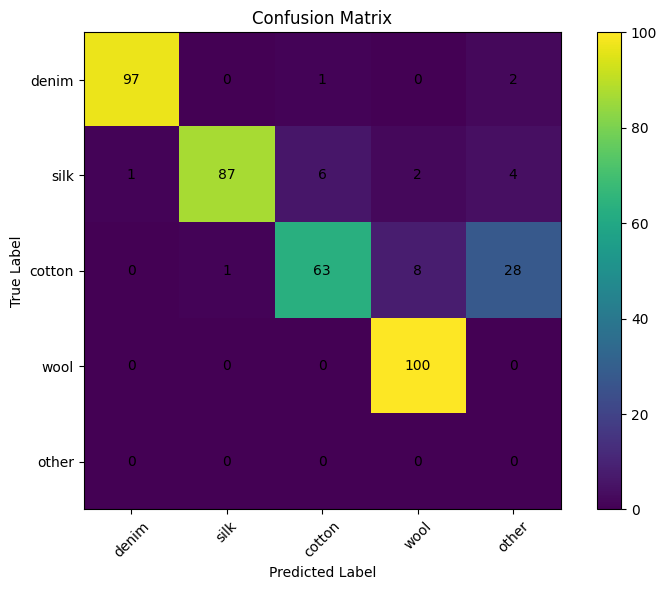

<Figure size 900x600 with 0 Axes>

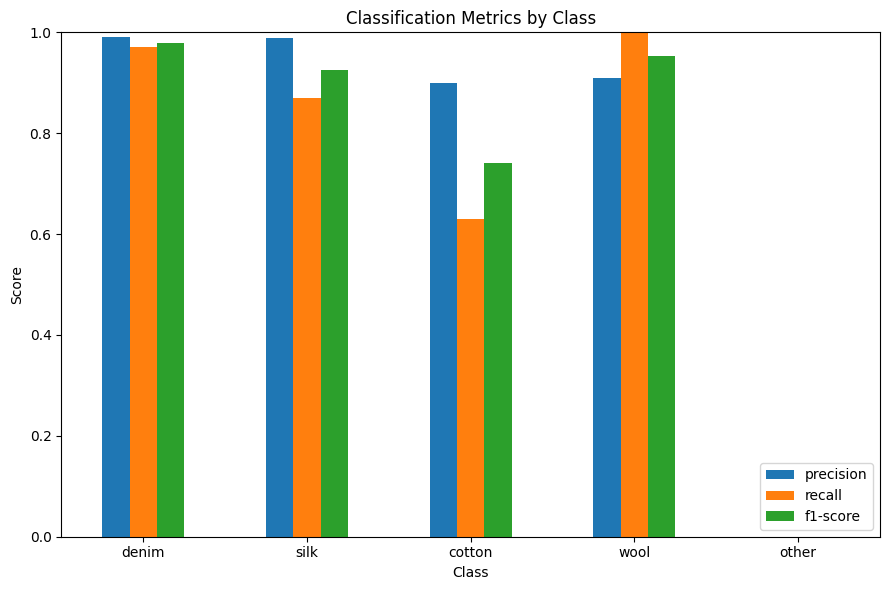

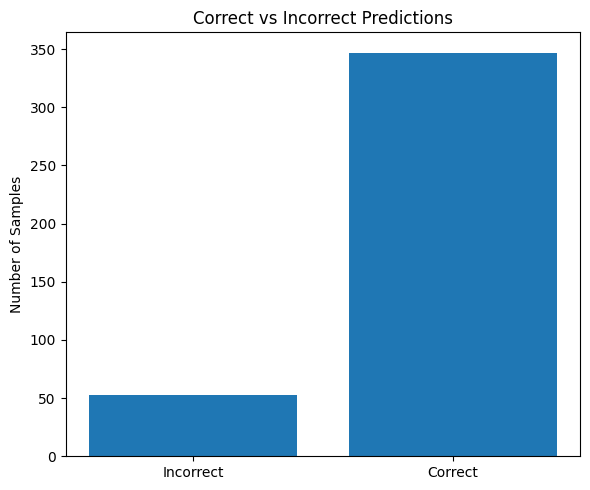

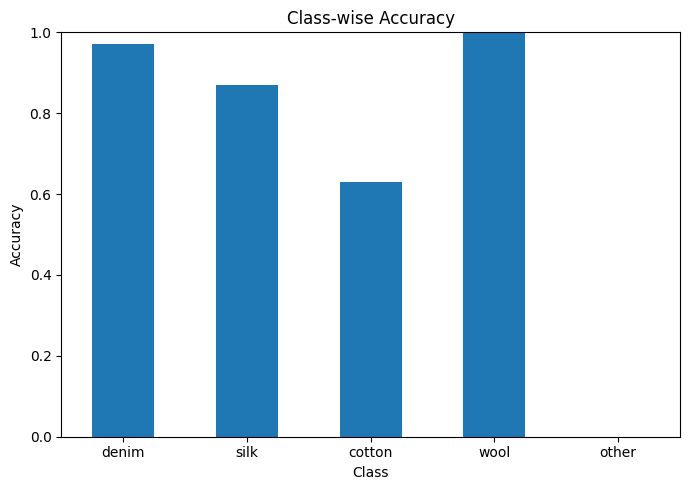

Saved files:
1. confusion_matrix.png
2. classification_metrics.png
3. correct_vs_incorrect.png
4. class_wise_accuracy.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report



labels = ["denim", "silk", "cotton", "wool", "other"]


cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

report = classification_report(
    y_true_labels,
    y_pred_labels,
    labels=labels,
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report).transpose().loc[
    labels, ["precision", "recall", "f1-score"]
]

plt.figure(figsize=(9, 6))
ax = df_report.plot(kind="bar", figsize=(9, 6))

plt.title("Classification Metrics by Class")
plt.ylabel("Score")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("classification_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

correct_counts = df_eval["is_correct"].value_counts()
incorrect_count = correct_counts.get(0, 0)
correct_count = correct_counts.get(1, 0)

plt.figure(figsize=(6, 5))
plt.bar(["Incorrect", "Correct"], [incorrect_count, correct_count])

plt.title("Correct vs Incorrect Predictions")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("correct_vs_incorrect.png", dpi=300, bbox_inches="tight")
plt.show()

class_accuracy = df_eval.groupby("label")["is_correct"].mean().reindex(labels)

plt.figure(figsize=(7, 5))
class_accuracy.plot(kind="bar")

plt.title("Class-wise Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("class_wise_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved files:")
print("1. confusion_matrix.png")
print("2. classification_metrics.png")
print("3. correct_vs_incorrect.png")
print("4. class_wise_accuracy.png")